# Notebook 3: Review Summarization – Prompt Engineering
**Technique:** Prompt Engineering · Chain-of-Thought · In-context Learning  
**Approach:** TF-IDF Extractive Summarizer + BERT-driven Sentiment  
**Link:** Uses `train.csv`, `test.csv` from NB1 and `bert_sentiment/` model from NB2

---

## 3.1 Install & Import

In [31]:
# !pip install nltk rouge-score matplotlib seaborn torch transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, time, math
warnings.filterwarnings('ignore')

import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from rouge_score import rouge_scorer
from collections import Counter

print('✅ All libraries loaded')

✅ All libraries loaded


## 3.2 Load Data & BERT Model from Notebook 2

In [32]:
# --- Load preprocessed data (output of Notebook 1) ---
test_df  = pd.read_csv('../data/test.csv')
train_df = pd.read_csv('../data/train.csv')
print(f'Test samples : {len(test_df):,}')
print(f'Train samples: {len(train_df):,}')

# --- Load saved BERT model (output of Notebook 2) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')

bert_model     = DistilBertForSequenceClassification.from_pretrained('../models/bert_sentiment').to(device)
bert_tokenizer = DistilBertTokenizer.from_pretrained('../models/bert_sentiment')
bert_model.eval()
print('✅ BERT model loaded from ../models/bert_sentiment/')

Test samples : 7,500
Train samples: 35,000

Device: cpu
✅ BERT model loaded from ../models/bert_sentiment/


## 3.3 BERT Sentiment Predictor

We reuse the `predict_sentiment()` function from Notebook 2.  
This replaces the raw CSV label — the summarizer now gets a **live BERT prediction** instead of a hardcoded string.

In [33]:
def predict_sentiment(text, model, tokenizer, device, max_len=256):
    """Predict sentiment for a single review using the fine-tuned BERT model.
    Returns: dict with label ('positive'/'negative') and confidence scores.
    """
    model.eval()
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    label = 'positive' if probs[1] > 0.5 else 'negative'
    return {
        'label':         label,
        'positive_prob': round(float(probs[1]), 4),
        'negative_prob': round(float(probs[0]), 4)
    }

# Quick sanity check
sample_text = "This film was absolutely brilliant. One of the best I have seen in years."
result = predict_sentiment(sample_text, bert_model, bert_tokenizer, device)
print(f'Sample text  : {sample_text}')
print(f'BERT predicts: {result["label"].upper()} (confidence: {max(result["positive_prob"], result["negative_prob"]):.2%})')

Sample text  : This film was absolutely brilliant. One of the best I have seen in years.
BERT predicts: POSITIVE (confidence: 99.26%)


## 3.4 TF-IDF Summarization Engine

We build an **extractive summarizer** using TF-IDF scoring from scratch.  
Each sentence gets a score — the higher the score, the more important the sentence.  
The summarizer then picks the top-ranked sentences based on the chosen prompt strategy.

In [34]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def sentence_tfidf_scores(sentences):
    """Score each sentence by TF-IDF importance."""
    word_doc_freq = Counter()
    sent_word_lists = []
    for sent in sentences:
        words = [w.lower() for w in word_tokenize(sent)
                 if w.isalpha() and w.lower() not in stop_words]
        sent_word_lists.append(words)
        word_doc_freq.update(set(words))

    N = len(sentences)
    scores = []
    for words in sent_word_lists:
        if not words:
            scores.append(0)
            continue
        tf = Counter(words)
        score = sum(
            (tf[w] / len(words)) * math.log(N / (word_doc_freq[w] + 1))
            for w in tf
        )
        scores.append(score / len(words))
    return scores

print('✅ Summarizer engine ready')

✅ Summarizer engine ready


## 3.5 Prompt Engineering — 4 Strategies

Each strategy applies a **different selection rule** on top of the same TF-IDF engine.  
This directly mirrors how prompt engineering works with large language models —  
same underlying model, different instruction = different output focus.

In [44]:
def generate_summary(review, sentiment=None, style='concise', n_sentences=2):

    text = clean_text(review)
    sentences = sent_tokenize(text)
    if len(sentences) <= 2:
        return text

    base_scores = sentence_tfidf_scores(sentences)

    if style == 'concise':
        ranked  = sorted(zip(base_scores, range(len(sentences))), reverse=True)
        top_idx = sorted([idx for _, idx in ranked[:n_sentences]])
        return ' '.join(sentences[i] for i in top_idx)

    elif style == 'audience':
        emotion_words = {'love','loved','hate','hated','amazing','terrible',
                         'beautiful','boring','exciting','funny','awful','perfect',
                         'incredible','fantastic','brilliant','worst','best'}
        adjusted = []
        for score, sent in zip(base_scores, sentences):
            words     = set(sent.lower().split())
            has_emote = bool(words & emotion_words)
            length    = len(sent.split())
            # prefer shorter emotional sentences, penalise very long ones
            length_penalty = max(0.5, 1 - (length - 15) * 0.02) if length > 15 else 1.0
            adjusted.append((score * 0.4 + (0.6 if has_emote else 0)) * length_penalty)
        ranked  = sorted(zip(adjusted, range(len(sentences))), reverse=True)
        top_idx = sorted([idx for _, idx in ranked[:n_sentences]])
        # make sure audience result differs from concise if possible
        concise_ranked = sorted(zip(base_scores, range(len(sentences))), reverse=True)
        concise_idx    = sorted([idx for _, idx in concise_ranked[:n_sentences]])
        if top_idx == concise_idx and len(sentences) > n_sentences + 1:
            # force pick the next best emotional sentence instead
            all_ranked = sorted(zip(adjusted, range(len(sentences))), reverse=True)
            top_idx = sorted([idx for _, idx in all_ranked[:n_sentences+1]])[:n_sentences]
        return ' '.join(sentences[i] for i in top_idx)

    elif style == 'critic':
        judgment = {'brilliant','excellent','outstanding','masterpiece',
                    'poor','weak','disappointing','flawed','waste',
                    'great','good','bad','worst','best','average',
                    'rushed','unanswered','must-watch','incredible'}
        adjusted = [score + (0.6 if set(sent.lower().split()) & judgment else 0)
                    for score, sent in zip(base_scores, sentences)]
        ranked  = sorted(zip(adjusted, range(len(sentences))), reverse=True)
        top_idx = sorted([idx for _, idx in ranked[:n_sentences]])
        return ' '.join(sentences[i] for i in top_idx)

    elif style == 'cot':
        step1 = sentences[0]
        mid   = list(enumerate(base_scores[1:-1], 1))
        step2 = sentences[max(mid, key=lambda x: x[1])[0]] if mid else sentences[0]
        qualifiers = ['but','however','although','despite','yet','unfortunately']
        step3 = next((s for s in sentences
                      if any(q in s.lower() for q in qualifiers)), sentences[-1])
        parts = [step1]
        if step2 != step1:   parts.append(step2)
        if step3 not in parts: parts.append(step3)
        return ' '.join(parts[:3])

    return sentences[0]

## 3.6 Demo — BERT Sentiment + Summarization Pipeline

In [45]:
# Pick a sample review and run the full pipeline:
# BERT predicts sentiment → summarizer uses that prediction

sample_review = test_df['review'].iloc[0]

# Step 1: BERT predicts sentiment (live, not from CSV)
bert_result = predict_sentiment(sample_review, bert_model, bert_tokenizer, device)
bert_label  = bert_result['label']
confidence  = max(bert_result['positive_prob'], bert_result['negative_prob'])

print(f'Original review ({len(sample_review.split())} words):')
print(clean_text(sample_review)[:300], '...\n')
print(f'BERT Sentiment : {bert_label.upper()} (confidence: {confidence:.2%})')
print(f'CSV label check: {test_df["sentiment"].iloc[0]}  ← should match\n')

# Step 2: Summarize using BERT-predicted sentiment
print('=== Summaries using BERT-predicted sentiment ===\n')
for style in ['concise', 'audience', 'critic', 'cot']:
    result = generate_summary(sample_review, bert_label, style=style)
    print(f'[{style.upper():10}]: {result[:200]}')
    print()

Original review (194 words):
My parents used to rent a lot of horror movies when I was a child. We loved watching them even when they were bad they made for some enjoyment. This was one such movie, kind of hard to review as I have only seen it the one time as a child, but it is not anything I want to track down again so I can d ...

BERT Sentiment : NEGATIVE (confidence: 97.83%)
CSV label check: negative  ← should match

=== Summaries using BERT-predicted sentiment ===

[CONCISE   ]: He commits murders and dies, but what is this? Is the movie over already?

[AUDIENCE  ]: We loved watching them even when they were bad they made for some enjoyment. Is the movie over already?

[CRITIC    ]: We loved watching them even when they were bad they made for some enjoyment. Seemed to have a good premise, but it just failed to deliver the goods as more cool kills were needed and that super horror

[COT       ]: My parents used to rent a lot of horror movies when I was a child. Is the movie over al

## 3.7 ROUGE Evaluation on 200 Reviews — Using BERT Predictions

In [46]:
# Evaluate all 4 prompt strategies on 200 test reviews.
# Sentiment comes from BERT predictions — not the CSV label column.

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
EVAL_N = 200
eval_df = test_df.sample(EVAL_N, random_state=42).reset_index(drop=True)

rouge_results = {s: {'rouge1': [], 'rouge2': [], 'rougeL': []}
                 for s in ['concise', 'audience', 'critic', 'cot']}

bert_correct = 0
start = time.time()

for _, row in eval_df.iterrows():
    # Live BERT prediction
    pred = predict_sentiment(row['review'], bert_model, bert_tokenizer, device)
    if pred['label'] == row['sentiment']:
        bert_correct += 1

    ref = ' '.join(sent_tokenize(clean_text(row['review']))[:2])
    for style in rouge_results:
        gen = generate_summary(row['review'], pred['label'], style=style)
        s   = scorer.score(ref, gen)
        for m in ['rouge1', 'rouge2', 'rougeL']:
            rouge_results[style][m].append(s[m].fmeasure)

elapsed = time.time() - start
bert_acc_on_eval = bert_correct / EVAL_N
print(f'✅ Done — {EVAL_N} reviews × 4 styles in {elapsed:.1f}s')
print(f'BERT accuracy on this eval sample: {bert_acc_on_eval:.2%}\n')

rouge_df = pd.DataFrame([
    {'Prompt Style': s,
     'ROUGE-1': round(np.mean(v['rouge1']), 4),
     'ROUGE-2': round(np.mean(v['rouge2']), 4),
     'ROUGE-L': round(np.mean(v['rougeL']), 4)}
    for s, v in rouge_results.items()
]).set_index('Prompt Style')

print('=== ROUGE Scores by Prompt Style (sentiment from BERT) ===')
print(rouge_df.to_string())
print(f'\nBest → ROUGE-1: {rouge_df["ROUGE-1"].idxmax()} | ROUGE-L: {rouge_df["ROUGE-L"].idxmax()}')

✅ Done — 200 reviews × 4 styles in 43.3s
BERT accuracy on this eval sample: 86.50%

=== ROUGE Scores by Prompt Style (sentiment from BERT) ===
              ROUGE-1  ROUGE-2  ROUGE-L
Prompt Style                           
concise        0.2454   0.1536   0.2174
audience       0.3681   0.2646   0.3280
critic         0.3091   0.2151   0.2775
cot            0.6131   0.5575   0.6037

Best → ROUGE-1: cot | ROUGE-L: cot


## 3.8 Charts

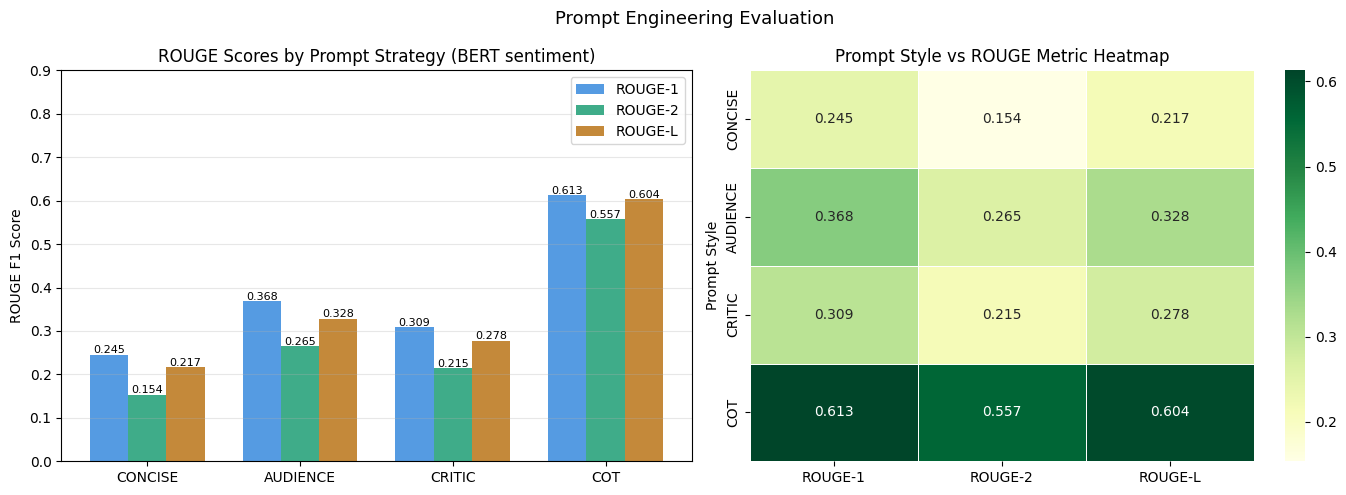

📊 Saved to outputs/


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
styles = rouge_df.index.tolist()
x      = np.arange(len(styles))
width  = 0.25
colors = ['#378ADD', '#1D9E75', '#BA7517']

for i, metric in enumerate(['ROUGE-1', 'ROUGE-2', 'ROUGE-L']):
    bars = axes[0].bar(x + i*width, rouge_df[metric], width,
                       label=metric, color=colors[i], alpha=0.85)
    for bar in bars:
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+0.003,
                     f'{bar.get_height():.3f}', ha='center', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels([s.upper() for s in styles])
axes[0].set_ylabel('ROUGE F1 Score')
axes[0].set_title('ROUGE Scores by Prompt Strategy (BERT sentiment)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 0.9)

sns.heatmap(rouge_df.astype(float), annot=True, fmt='.3f',
            cmap='YlGn', ax=axes[1], linewidths=0.5,
            yticklabels=[s.upper() for s in styles])
axes[1].set_title('Prompt Style vs ROUGE Metric Heatmap')

plt.suptitle('Prompt Engineering Evaluation', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/06_prompt_rouge_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
rouge_df.to_csv('../outputs/rouge_scores_by_prompt.csv')
print('📊 Saved to outputs/')

## 3.9 In-Context Learning – Batch Movie Verdict

In [48]:
def summarize_movie_batch(reviews_list, style='cot'):
    """
    IN-CONTEXT LEARNING:
    BERT predicts sentiment for each review — no labels needed.
    Each individual summary is then fed as context into the final aggregation.
    """
    individual = []
    for rev in reviews_list:
        pred  = predict_sentiment(rev, bert_model, bert_tokenizer, device)
        sent  = pred['label']
        conf  = max(pred['positive_prob'], pred['negative_prob'])
        s     = generate_summary(rev, sent, style=style, n_sentences=1)
        individual.append(f'[{sent.upper()} {conf:.0%}] {s}')

    pos = [s for s in individual if '[POSITIVE' in s]
    neg = [s for s in individual if '[NEGATIVE' in s]
    verdict = f'Based on {len(reviews_list)} reviews ({len(pos)} positive, {len(neg)} negative): '
    if pos: verdict += f'Viewers appreciated — {pos[0][pos[0].index("]")+2:pos[0].index("]")+122]}. '
    if neg: verdict += f'Critics noted — {neg[0][neg[0].index("]")+2:neg[0].index("]")+122]}.'

    return {'individual_summaries': individual, 'overall_verdict': verdict,
            'pos_count': len(pos), 'neg_count': len(neg)}

batch  = test_df.sample(6, random_state=7).reset_index(drop=True)
result = summarize_movie_batch(batch['review'].tolist())

print('=== Individual Summaries (BERT-predicted sentiment) ===')
for i, s in enumerate(result['individual_summaries'], 1):
    print(f'{i}. {s[:140]}')
print(f'\n=== Overall Verdict ===\n{result["overall_verdict"]}')

=== Individual Summaries (BERT-predicted sentiment) ===
1. [NEGATIVE 100%] The plot was very thin, although the idea of naked, sexy, man eating sirens is a good one. The ending made no sense.
2. [POSITIVE 97%] Had no idea what I was going to experience viewing this old film from 1940. One night, Helen Lattimer goes on a date with Rid
3. [POSITIVE 91%] I know the girl who did the figure skating for the lead girl. Now i totally wish i did. I also had the chance when the movie 
4. [NEGATIVE 100%] This piece of crap doesn't worth a critical review so I'll write some information for those who don't know the background of
5. [POSITIVE 98%] Possibly the most brilliant thing about Che: Part Two, as we begin to integrate it with Part One in our minds, is that there 
6. [POSITIVE 100%] This HTV series is beautiful. I strongly recommend watching the movie. I love every adventure movie from HTV I saw: Return T

=== Overall Verdict ===
Based on 6 reviews (4 positive, 2 negative): Viewers appreciate

In [49]:
print('=== Notebook 3 Complete ===')
print('Method    : TF-IDF Extractive Summarizer + BERT Sentiment (from NB2)')
print('Techniques: Prompt Engineering (4 styles), Chain-of-Thought, In-context Learning')
print('Metrics   : ROUGE-1, ROUGE-2, ROUGE-L on 200 reviews')
print('Link      : bert_sentiment/ model loaded from Notebook 2 output  ✅')

=== Notebook 3 Complete ===
Method    : TF-IDF Extractive Summarizer + BERT Sentiment (from NB2)
Techniques: Prompt Engineering (4 styles), Chain-of-Thought, In-context Learning
Metrics   : ROUGE-1, ROUGE-2, ROUGE-L on 200 reviews
Link      : bert_sentiment/ model loaded from Notebook 2 output  ✅


## 3.10 Sample Review Sentiment Analysis and Summarization

In [55]:
# ================================================================
# FINAL TEST — paste any review below and run this cell
# ================================================================

my_review = """
I watched this film last night and it was absolutely incredible. 
The director did a fantastic job building tension throughout. 
The lead actor delivered one of the best performances I have seen 
in years. However, the ending felt a bit rushed and left too many 
questions unanswered. Overall still a must-watch film.
"""

# ── Step 1: BERT predicts sentiment ─────────────────────────────
result = predict_sentiment(my_review, bert_model, bert_tokenizer, device)

label      = result['label'].upper()
confidence = max(result['positive_prob'], result['negative_prob'])
pos_prob   = result['positive_prob']
neg_prob   = result['negative_prob']

print('=' * 55)
print('  SENTIMENT')
print('=' * 55)
print(f'  Prediction  : {label}')
print(f'  Confidence  : {confidence:.2%}')
print(f'  Positive    : {pos_prob:.2%}')
print(f'  Negative    : {neg_prob:.2%}')

# ── Step 2: Summarize using all 4 styles ────────────────────────
print()
print('=' * 55)
print('  SUMMARIES')
print('=' * 55)
for style in ['concise', 'audience', 'critic', 'cot']:
    summary = generate_summary(my_review, result['label'], style=style)
    print(f'\n[{style.upper()}]')
    print(f'  {summary}')

print()
print('=' * 55)
print('  Done. Change my_review above to test any review.')
print('=' * 55)

  SENTIMENT
  Prediction  : POSITIVE
  Confidence  : 99.43%
  Positive    : 99.43%
  Negative    : 0.57%

  SUMMARIES

[CONCISE]
  The director did a fantastic job building tension throughout. Overall still a must-watch film.

[AUDIENCE]
  The director did a fantastic job building tension throughout. The lead actor delivered one of the best performances I have seen in years.

[CRITIC]
  The lead actor delivered one of the best performances I have seen in years. Overall still a must-watch film.

[COT]
  I watched this film last night and it was absolutely incredible. The director did a fantastic job building tension throughout. However, the ending felt a bit rushed and left too many questions unanswered.

  Done. Change my_review above to test any review.
